In [4]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
random.seed(42) # define the seed (important to reproduce the results)

#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/BreastCancer.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))
#data = pd.read_csv('data/Vehicle.csv', header=(0))
data = pd.read_csv('winequality-red.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes

nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)
data.head(10)

Matriz de atributos: Número de linhas: 1599  colunas:  12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


Vamos construir as variáveis  𝑋  e  𝑦 , sendo que o processo classificação se resume em estimar a função  𝑓  na relação  𝑦=𝑓(𝑋)+𝜖 , onde  𝜖  é o erro, que tem distribuição normal com média igual a zero e variância  𝜎2 .

Convertemos os dados para o formato Numpy para facilitar a sua manipulação.

In [5]:
y = data.iloc[:,-1]
classes = np.array(pd.unique(y))
data = data.to_numpy()
nrow,ncol = data.shape
X = data[:,0:ncol-1]

Para treinar o classificador, precisamos definir o conjunto de teste e treinamento.

In [6]:
from sklearn.model_selection import train_test_split
p = 0.7 # fracao de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

Classificador Bayesiano

Vamos considerar o caso paramétrico, assumindo que cada variável está distribuída de acordo com uma distribuição Normal. Outras distribuições também podem ser utilizadas.

Já selecionamos os conjuntos de treinamento e teste anteriormente. No conjunto de treinamento, vamos calcular a média e desvio padrão de cada atributo para cada classe. A seguir, reaizamos a classificação, dos dados usando a teoria da decisão Bayesiana, isto é:  𝑋∈𝐶𝑖  se, e somente se,  𝑃(𝐶𝑖|𝑋)=max𝑃(𝐶𝑗|𝑋)  para todo  𝑗 .

In [7]:
from scipy.stats import multivariate_normal

#matrix to store the probabilities
P = pd.DataFrame(data=np.zeros((X_test.shape[0], len(classes))), columns = classes) 
Pc = np.zeros(len(classes)) #fraction of elements in each class
for i in np.arange(0, len(classes)):
    elements = np.array(np.where(y_train == classes[i]))
    Pc[i] = elements.shape[1]/len(y_train)
    Z = X_train[elements,:][0].astype(float)
    m = np.mean(Z, axis = 0)
    cv = np.cov(np.transpose(Z))
    for j in np.arange(0,X_test.shape[0]):
        x = X_test[j,:]
        pj = multivariate_normal.pdf(x, mean=m, cov=cv, allow_singular=True)
        #P[classes[i]][j] = pj*Pc[i]
        P.loc[j,classes[i]] = pj*Pc[i]

In [8]:
print(P)

            5         6         7             4    8    3
0    0.781664  0.663999  0.006833  9.113895e-03  0.0  0.0
1    0.062489  0.001753  0.000258  6.823027e-05  0.0  0.0
2    0.003754  0.034498  0.004914  2.664282e-05  0.0  0.0
3    0.175046  0.105331  0.009967  7.523777e-05  0.0  0.0
4    0.396246  1.771192  0.259347  8.645114e-03  0.0  0.0
..        ...       ...       ...           ...  ...  ...
475  0.014908  0.010123  0.002588  3.138699e-06  0.0  0.0
476  0.068360  0.739137  0.826187  2.908261e-04  0.0  0.0
477  0.396246  1.771192  0.259347  8.645114e-03  0.0  0.0
478  0.000407  0.031980  0.042355  5.930039e-07  0.0  0.0
479  0.148611  0.154740  0.032276  4.880551e-03  0.0  0.0

[480 rows x 6 columns]


Classifica de acordo com a classe mais provável:

In [9]:
y_pred = []
#np.array(test_x.shape[0], dtype=str)
for i in np.arange(0, X_test.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(classes[c])
y_pred = np.array(y_pred)
y_test = np.array(y_test)
print(y_pred)

[5 5 6 5 6 5 5 5 6 6 7 5 6 5 6 7 5 6 7 5 6 6 6 7 6 6 6 6 5 7 5 6 6 5 6 5 6
 6 5 6 5 5 6 5 6 6 7 6 5 6 5 4 6 7 5 5 6 6 6 5 5 6 5 6 6 5 6 6 6 5 7 5 6 6
 6 5 7 6 7 7 5 7 6 6 6 6 5 6 7 5 6 7 6 6 5 5 5 5 5 6 5 5 6 6 5 6 6 5 7 5 7
 5 6 5 6 6 6 6 5 6 6 6 6 6 6 5 7 6 6 6 6 5 5 6 6 5 5 5 5 6 7 5 6 6 6 5 6 6
 6 5 6 6 6 6 6 6 6 6 5 6 7 6 7 5 5 6 5 5 5 5 5 5 7 6 7 6 7 5 5 5 5 7 5 7 5
 7 5 6 7 6 6 6 6 6 6 5 5 5 6 6 5 5 5 5 7 6 5 7 6 6 6 5 6 7 6 6 5 5 6 6 6 7
 7 6 4 5 5 7 5 6 6 6 6 6 6 6 5 6 5 5 6 5 7 6 4 7 6 5 7 5 6 6 5 6 5 5 5 6 6
 7 6 6 5 6 6 6 5 5 6 6 5 6 5 5 5 6 5 7 6 6 7 5 6 5 5 6 5 5 6 4 5 7 6 5 5 6
 5 6 6 6 6 5 7 5 6 6 6 7 6 7 6 6 6 5 5 6 5 5 6 5 6 7 6 5 5 5 6 6 5 7 6 7 5
 6 6 6 6 6 5 5 7 6 6 5 7 5 6 5 6 6 5 6 6 5 6 6 6 5 5 6 6 5 5 6 4 6 6 5 5 5
 5 5 6 6 5 6 6 6 6 6 5 6 6 5 7 6 6 5 5 6 6 6 5 6 6 6 7 6 5 7 6 5 6 5 5 6 7
 6 5 4 6 7 7 6 6 7 5 7 5 7 7 5 6 5 6 6 6 5 6 5 7 5 6 5 7 6 5 5 5 7 6 6 6 5
 6 5 5 6 5 4 7 6 6 5 6 7 7 5 6 5 4 4 4 5 6 5 6 6 6 6 7 6 6 6 5 5 7 6 7 6]


In [10]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.5708333333333333


Caso não paramétrico

Para o caso unidimensional, seja  (𝑋1,𝑋2,…,𝑋𝑛)  uma amostra aleatória unidimensional identicamente distribuída de acordo com alguma função de distribuição  𝑓  não conhecida. Para estimarmos o formato de  𝑓 , usamos um estimador (kernel density estimator):
𝑓ˆℎ(𝑥)=1𝑛∑𝑖=1𝑛𝐾ℎ(𝑥−𝑥𝑖)=1𝑛ℎ∑𝑖=1𝑛𝐾(𝑥−𝑥𝑖ℎ), 
onde  𝐾  é a função kernel. A estimação depende do parâmetro  ℎ , que é um parâmetro livre e controla a abertura da função.

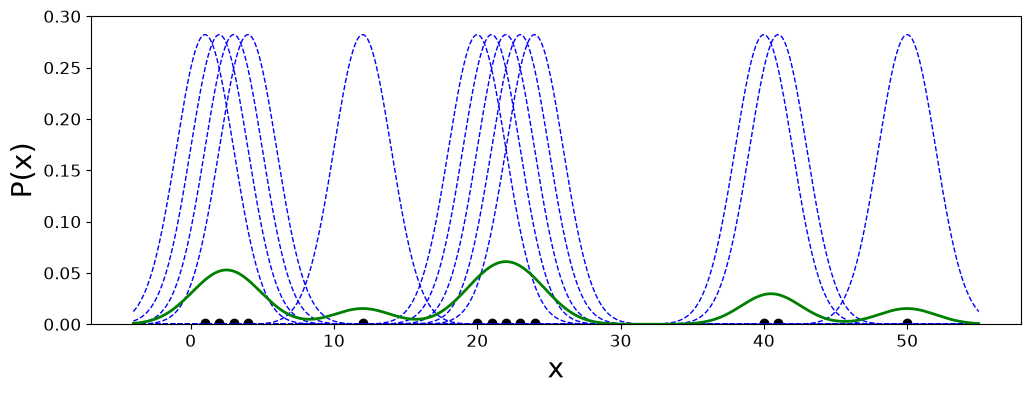

In [11]:
import numpy as np
import matplotlib.pyplot as plt

N = 20
# gera os dados
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))
# mostra os dados
plt.figure(figsize=(12,4))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

# valores x para serem usados nas densidades
X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0 # estimacao obtida
for x in X:
    # distribuição normal centrada em x
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    fhat = fhat + f # acumula as distribuições
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

# mostra a distribuição estimada
plt.plot(X_plot,fhat/(len(X)*np.sqrt(h)), color = 'green', linewidth=2)
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(x)', fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))
plt.savefig('kernel-ex.eps')
plt.show(True)

Esse resultado pode ser obtido usando-se a função KernelDensity scikit-learn.

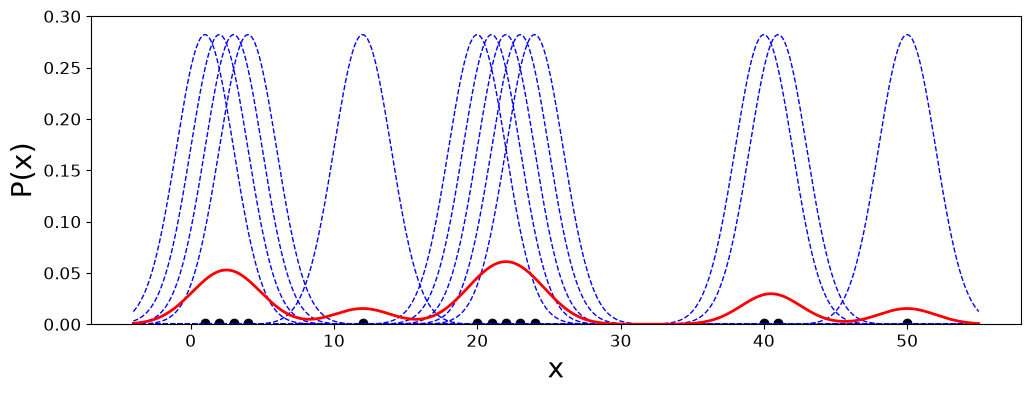

In [12]:
import numpy as np
from matplotlib.pyplot import cm
from sklearn.neighbors import KernelDensity

color=['red', 'blue', 'magenta', 'gray', 'green']

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

plt.figure(figsize=(12,4))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0
for x in X:
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    fhat = fhat + f
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
plt.plot(X_plot,log_dens, color = 'red', linewidth=2, label = 'h='+str(h))    
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(x)', fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))

plt.show(True)

Notem que o formato da estimação depende do parâmetro livre $h$.

In [16]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import accuracy_score

random.seed(42)
#data = pd.read_csv('data/Iris.csv', header=(0))
data = pd.read_csv('Vehicle.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.7 # fraction of elements in the training set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

# Matriz que armazena as probabilidades para cada classe
P = pd.DataFrame(data=np.zeros((x_test.shape[0], len(classes))), columns = classes) 
Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
h = 2
for i in np.arange(0, len(classes)): # Para cada classe
    elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
    Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
    Z = x_train[elements,:][0].astype(float) # Elementos no conjunto de treinamento
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
    for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
        x = x_test[j,:]
        x = x.reshape((1,len(x)))
        # calcula a probabilidade pertencer a cada classe
        pj = np.exp(kde.score_samples(x)) 
        #P[classes[i]][j] = pj*Pc[i]
        P.loc[j,classes[i]] = pj*Pc[i]
        
y_pred = [] # Vetor com as classes preditas
for i in np.arange(0, x_test.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(classes[c])
y_pred = np.array(y_pred, dtype=str)
# calcula a acuracia
score = accuracy_score(y_pred, y_test)
print('Acuracia:', score)

Acuracia: 0.6181102362204725


# Classificador Naive

In [18]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
data = pd.read_csv('winequality-red.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns)
data.head(10)

Número de linhas e colunas na matriz de atributos: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [19]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

In [20]:
from sklearn.model_selection import train_test_split
p = 0.2 # fraction of elements in the training set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

model = GaussianNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print('Accuracy: ', model.score(x_test, y_test))

Accuracy:  0.55
